PRIMER PARCIAL - PROCESAMIENDO DIGITAL DE IMÁGENES

1. Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada casilla debe medir 100x100 px como se muestra en una imagen a continuación

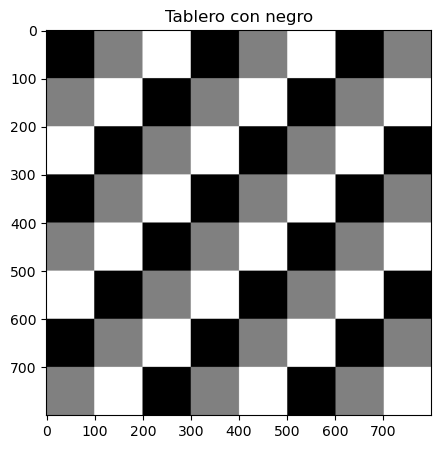

In [100]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

tamano = 100
tablero = np.zeros((8*tamano, 8*tamano, 3), dtype=np.uint8)

negro = (0, 0, 0)
blanco = (255, 255, 255)
plomo = (128, 128, 128)
colores = [negro, plomo,blanco]

for i in range(8):
    for j in range(8):
        color = colores[(i + j) % 3]
        tablero[i*tamano:(i+1)*tamano, j*tamano:(j+1)*tamano] = color

plt.imshow(tablero)
plt.title('Tablero con negro')
plt.show()


2. Genera una imagen como la de referencia

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

tamano = 100
bandera = np.zeros((8*tamano, 8*tamano, 3), dtype=np.uint8)

colores = [verde, amarillo, azul]


3. Haciendo uso de la imagen obttiene el siguiente resultado

In [98]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('1erP.jpeg')
rows, cols = imagen.shape
deg_imagen = np.tile(np.linspace(255, 0, cols, dtype=np.uint8), (rows, 1))
imagen_degradada = cv2.addWeighted(imagen, 0.5, deg_imagen, 0.5, 0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(imagen_degradada, cmap='gray')
plt.title('Imagen con Degradado')

plt.show()


ValueError: too many values to unpack (expected 2)

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap 

imagen = cv2.imread('1erP.jpeg')
imagen_gray=cv2.imread('1erP.jpeg',0)

ecualizada=cv2.equalizeHist(imagen)
ecu_color=cv2.merge([cv2.equalizeHist(imagen[:,:,0]),cv2.equalizeHist(imagen[:,:,1]),cv2.equalizeHist(imagen[:,:,2])])
cmap=LinearSegmentedColormap.from_list('degradado',ecu_color)#listar los colores y generara color map a traves del array
imagen_degradado=cmap(np.linspace(0,1,256).reshape(-1,1))


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(imagen)
plt.title('Imagen Original')

plt.subplot(1,2,2)
plt.title('Imagen con Degradado')
plt.imshow(imagen_degradado)

plt.show()

error: OpenCV(4.11.0) D:\bld\libopencv_1739279478191\work\modules\imgproc\src\histogram.cpp:3440: error: (-215:Assertion failed) _src.type() == CV_8UC1 in function 'cv::equalizeHist'


4. Haciendo uso de la imagen obtiene el siguiente resultado

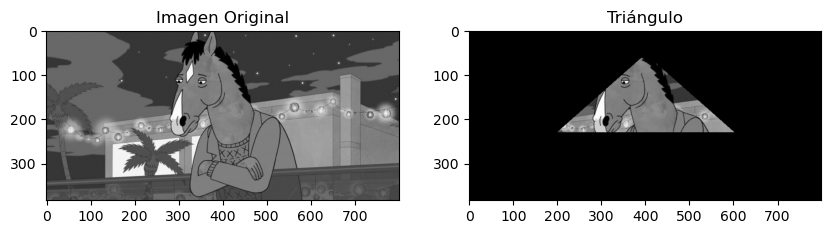

In [91]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('1erP.jpeg', 0)

alto, ancho = imagen.shape[:2]
mascara = np.zeros_like(imagen)

puntos = np.array([[ancho // 2, alto // 7],  [ancho // 4, 3 * alto // 5], [3 * ancho // 4, 3 * alto // 5]  ], np.int32)

cv2.fillPoly(mascara, [puntos], 255)

img_mascara = cv2.bitwise_and(imagen, imagen, mask=mascara)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(img_mascara, cmap='gray')
plt.title('Triángulo')

plt.show()


5. Tomando en cuenta la imagen elige un punto de interés al azar (función randomica), genera su histograma por canales, solariza y posteriza la imagen, realiza un tratamiento de umbralización (el de preferencia, mezcla tecnicas y obtiene un filtro artistico, lista todas las imagenes con sus correspondientes títulos, guarda todas las imágenes, resultantes con sus nombres)

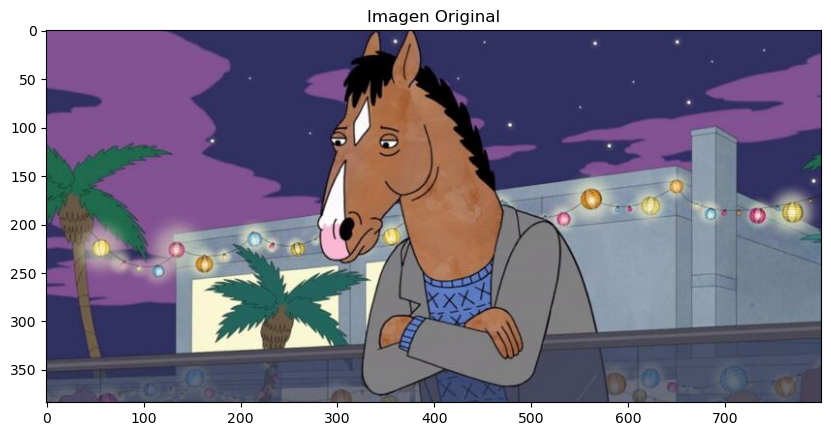

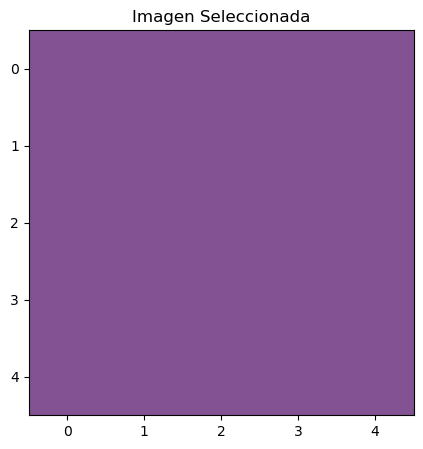

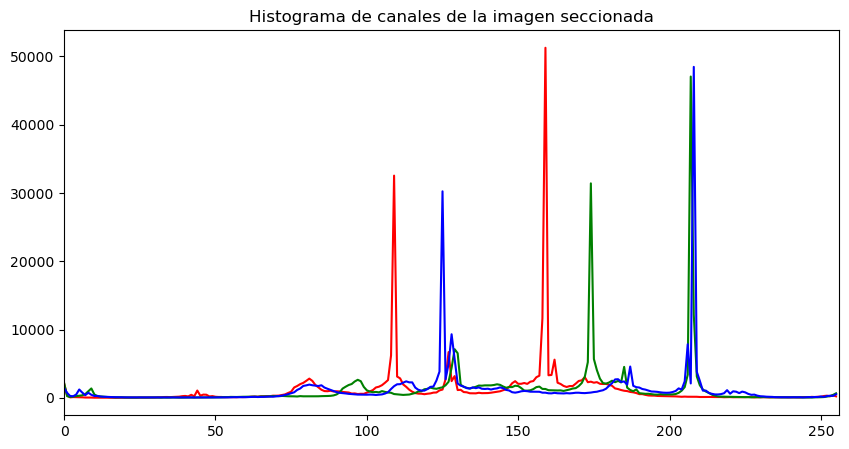

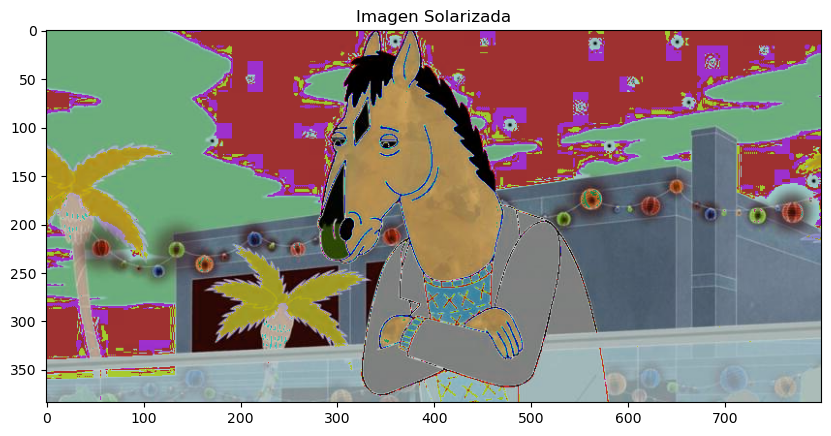

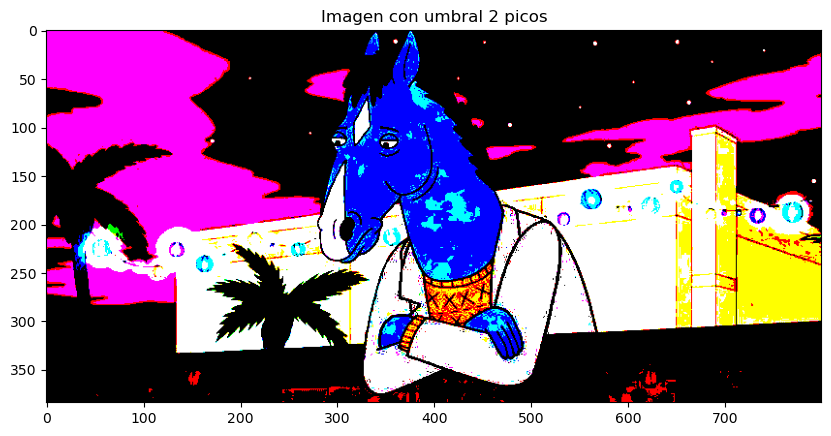

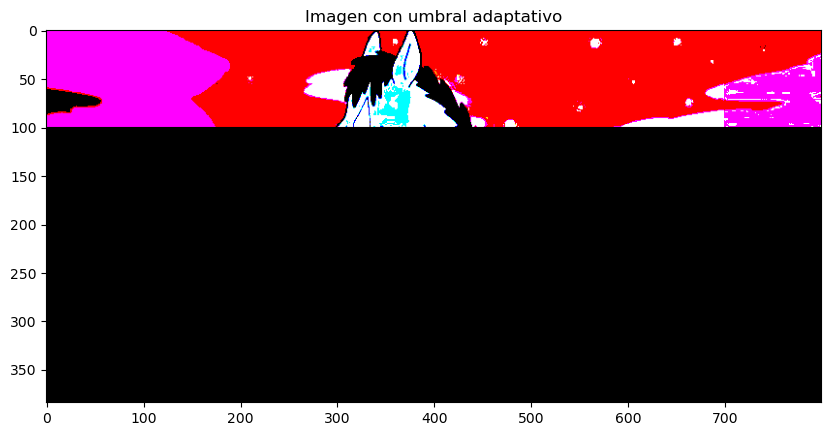

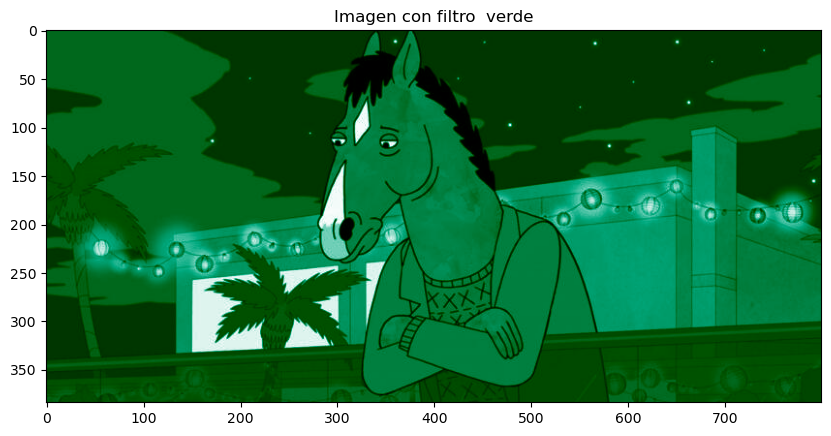

In [45]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

#Imagen Original
plt.rcParams['figure.figsize']=[10,5]
imagen= cv2.imread('1erP.jpeg')
imagen_rgb=cv2.cvtColor(imagen, cv2.COLOR_RGB2BGR)
plt.imshow(imagen_rgb)
plt.title('Imagen Original')
plt.show()


#Imagen seccionada
plt.imshow(imagen_rgb[100:105,30:35,:])
plt.title('Imagen Seleccionada')
plt.show()

#Guardado de imagen seleccionada
img_cortada=imagen_rgb[100:105,50:55,:]
plt.imsave('img_cortada.jpg',img_cortada)

#Histograma de canales de la imagen Seccionada
secciona= cv2.imread('1erP.jpeg')
color=('r','g','b')
for canal,col in enumerate(color):
    histograma=cv2.calcHist([secciona*255],[canal],None,[256],[0,256])
    plt.plot(histograma, color=col)
    plt.xlim([0,256])
plt.title('Histograma de canales de la imagen seccionada')
plt.show()


#Guardado del histograma de canales de la imagen seccionada
plt.imsave('img_histogramaCanales.jpg', histograma)

#Solarización
def solarizar(imagen, umbral):
    imagen_solarizada = np.where(imagen<umbral,imagen,255-imagen)
    return imagen_solarizada
img_gris=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)

nivel= 50
newim = solarizar(imagen,nivel)

plt.figure(figsize=(10,5))
plt.imshow(newim,cmap='gray')
plt.title('Imagen Solarizada')
plt.show()

#Guardado imagen solarizada
plt.imsave('img_solarizacion.jpg', newim)

#Técnica de Picos
def dos_picos(imagen):
    hist=cv2.calcHist([imagen],[0], None,[256], [0,256])
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico)
    primer_pico=np.argmax(pico_dif[:128])
    segundo_pico=np.argmin(pico_dif[128:])+128
    umbral_2picos=(primer_pico+segundo_pico)/2
    return umbral_2picos

umbral_2pic=dos_picos(imagen)
_,imagen_2pic=cv2.threshold(imagen, umbral_2pic,255,cv2.THRESH_BINARY)
plt.title('Imagen con umbral 2 picos')
plt.imshow(imagen_2pic, cmap='gray')
plt.show()

#Guardado imagen de 2 picos
plt.imsave('img_2picos.jpg', imagen_2pic)

#Umbralización Variable - Partición de una imagen
def variable_umb_blok(image,tam_bloq,c):
    umbral_ima=np.zeros_like(image)
    for y in range(0,image.shape[0], tam_bloq):
        for x in range(0,image.shape[1],tam_bloq):
            bloque= image[y:y+tam_bloq,x:x+tam_bloq]
            bloque_media=np.mean(bloque)
            umbral_adap=bloque_media-c
            umbral_ima[y:y+tam_bloq,x:x+tam_bloq]=(bloque>umbral_adap)*255
        return umbral_ima

tam_bloq=100 #se cambia el tamaño del bloquee
c=10
umbral_img_adap=variable_umb_blok(imagen,tam_bloq,c)

plt.title('Imagen con umbral adaptativo')
plt.imshow(umbral_img_adap, cmap='gray')
plt.show()

#Guardado imagen con umbralización adaptativo
plt.imsave('img_umbAdap.jpg', umbral_img_adap)



#filtro verde
def falso_color(img_gray):
    scale_img = cv2.normalize(img_gray,None,0,255,cv2.NORM_MINMAX)
    apcol = cv2.applyColorMap(scale_img, cv2.COLORMAP_DEEPGREEN)
    return apcol


newim2 = falso_color(imagen)
plt.imshow(cv2.cvtColor(newim2,cv2.COLOR_BGR2RGB))
plt.title('Imagen con filtro  verde')
plt.show()


#Guardado imagen con filtro verde
plt.imsave('img_filtro.jpg', newim2)

PREGUNTAS TEÓRICAS

¿A qué nos referimos si hablamos de una imagen digital?

Conjunto de Pixeles que forman una imagen

¿Qué es la profundidad del Color?

Es la cantidad de intensidad que se ingresa a cada pixel

¿Cuál es la diferecia entre CMKY Y RGB?

Se diferencia con los colores bases que tiene cada uno, RGB tiene los colores basicos, mientras que CMKY tiene más colores.